# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [4]:
df = pd.read_csv('student_lifestyle_performance_dataset.csv')
sorted_df = df.sort_values(by='CGPA', ascending=False).head(15)
sorted_df[["Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week"]]



,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week
657,22,6.85,8.45,3.84,12.67
109,23,5.83,9.26,7.19,6.05
843,24,4.64,8.34,3.28,3.59
405,17,6.87,7.92,2.21,18.13
464,25,5.18,9.13,7.92,7.85
171,20,8.05,7.34,6.46,0.00
475,19,5.71,8.07,2.98,12.96
639,19,7.30,8.57,3.96,8.24
659,20,3.85,9.22,7.14,5.21
682,25,4.87,8.25,4.95,0.00


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [5]:
df["Free_Time"] = 24-df['Gym_Hours_per_Week']/7-df['Study_Hours_per_Day']-2.5-df['Sleep_Hours']-df["Screen_Time_Hours"]+1

mask = df["Screen_Time_Hours"] < 1

df.loc[mask, "Free_Time"] = df["Free_Time"] - 1 + df["Screen_Time_Hours"]

df["Free_Time"] = df["Free_Time"].round(2)

df[["Free_Time", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week"]]

,Free_Time,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week
0,1.91,4.14,6.84,9.23,2.67
1,5.69,5.97,5.52,3.09,15.61
2,10.54,3.19,3.39,5.02,2.52
3,2.08,4.77,6.44,9.21,0.00
4,4.36,5.42,6.54,4.76,9.93
...,...,...,...,...,...
995,6.60,4.60,5.26,4.23,12.64
996,7.64,4.02,6.55,3.88,2.86
997,5.15,4.28,8.43,4.64,0.00
998,3.74,6.42,6.06,4.84,10.08


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [6]:
adults_df = df[df["Age"] >=18]

adults_df.groupby(["Branch"])["Stress_Level_1_to_10"].mean().sort_values(ascending=False)


,Stress_Level_1_to_10
Branch,
Civil,4.630494
ECE,4.626014
Mechanical,4.608940
Electrical,4.544621
CSE,4.526667
IT,4.454929


In [7]:
adults_df.groupby(["Branch"])["Sleep_Hours"].median().sort_values(ascending=False)

,Sleep_Hours
Branch,
IT,6.755
Civil,6.710
Mechanical,6.640
CSE,6.540
ECE,6.405
Electrical,6.310


Wyższa mediana snu - Mechanical

## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

<Axes: xlabel='Sleep_Hours', ylabel='CGPA'>

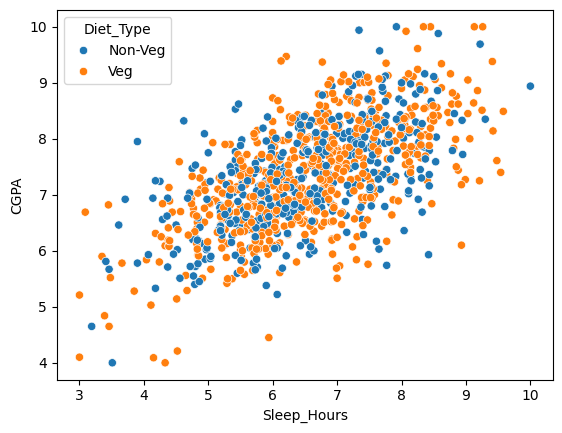

In [8]:
sns.scatterplot(data=df, x="Sleep_Hours", y="CGPA", hue="Diet_Type")

<Axes: xlabel='Branch', ylabel='Attendance_Percentage'>

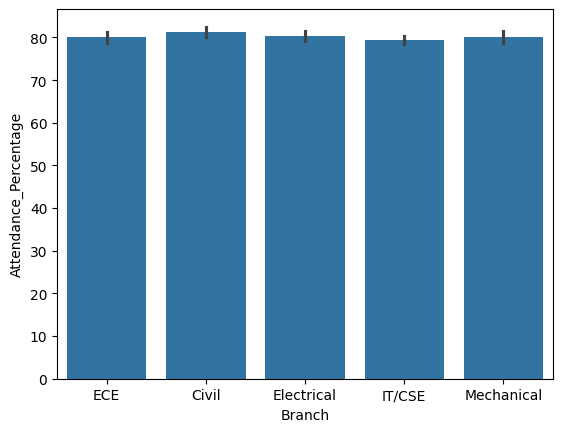

In [9]:
df['Branch'] = df['Branch'].replace(['CSE', 'IT'], 'IT/CSE')

sns.barplot(data=df, x="Branch", y="Attendance_Percentage")

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?

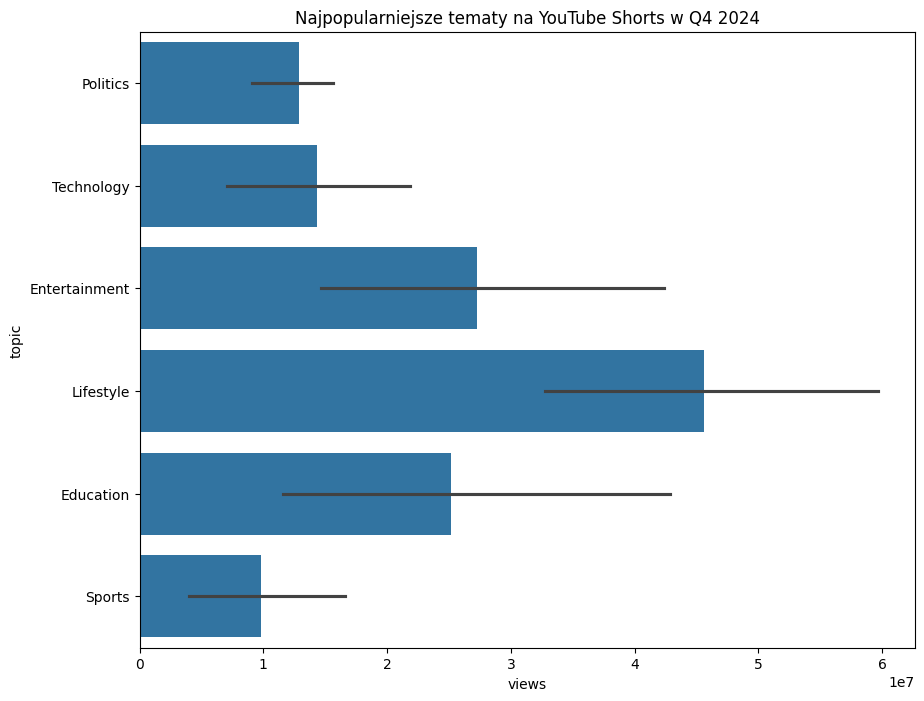

In [14]:
df = pd.read_csv("social_media_viral_content_dataset.csv")

df["post_datetime"] = pd.to_datetime(df["post_datetime"])
yt_df = df[
    (df["platform"] == "YouTube Shorts") &
    (df["post_datetime"].dt.year == 2024) &
    (df["post_datetime"].dt.month >= 10) &
    (df["content_type"] == "video")
]

plt.figure(figsize=(10, 8))
sns.barplot(
    data=yt_df,
    x="views",
    y="topic",
    estimator=sum
)

plt.title('Najpopularniejsze tematy na YouTube Shorts w Q4 2024')
plt.show()

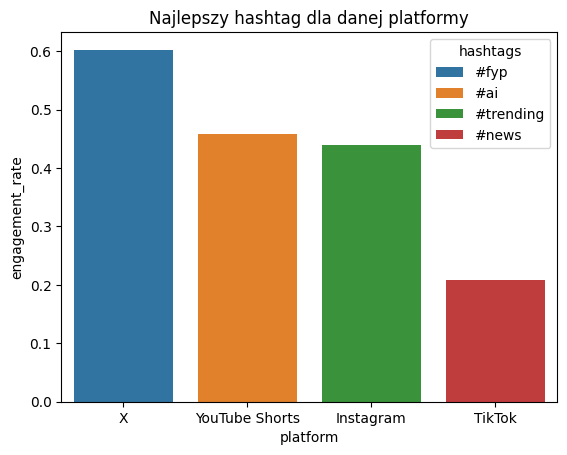

In [18]:
df["hashtags"] = df["hashtags"].str.split()

df = df.explode("hashtags")

hashtag_df = df.groupby(["platform", "topic", "hashtags"])["engagement_rate"].mean().reset_index()

hashtag_df_sorted = hashtag_df.sort_values(by="engagement_rate", ascending=False)
hashtag_df_sorted = hashtag_df_sorted.drop_duplicates(subset="platform")

sns.barplot(
    data=hashtag_df_sorted,
    x="platform",
    y="engagement_rate",
    hue="hashtags"
)

plt.title("Najlepszy hashtag dla danej platformy")
plt.show()